In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_excel('Data/Telco_customer_churn.xlsx')

In [3]:
dataset.head(3)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


In [62]:
df = dataset.copy()

In [63]:
df.columns = [x.lower() for x in df.columns]

In [64]:
# As per EDA - Count, Country, State, having only one unique value and CustomerId also not usefull for coustomer churn prediction.
df.drop(columns=['country', 'customerid', 'state', 'city', 'lat long'], axis=1,inplace=True)

In [65]:
categorical_feature = [x for x in df.columns if df[x].dtype == 'object' ]

In [66]:
categorical_feature

['gender',
 'senior citizen',
 'partner',
 'dependents',
 'phone service',
 'multiple lines',
 'internet service',
 'online security',
 'online backup',
 'device protection',
 'tech support',
 'streaming tv',
 'streaming movies',
 'contract',
 'paperless billing',
 'payment method',
 'total charges',
 'churn label',
 'churn reason']

# Handling Categorical feature --

In [67]:
# gender
df['gender'] = df['gender'].map({
    'Male' : 0,
    'Female' : 1
})

In [68]:
df['gender']

0       0
1       1
2       1
3       1
4       0
       ..
7038    1
7039    0
7040    1
7041    1
7042    0
Name: gender, Length: 7043, dtype: int64

In [69]:
# senior citizen
df['senior citizen'] = df['senior citizen'].map({
    'No' : 1,
    'Yes' : 0
})

In [70]:
df['senior citizen']

0       1
1       1
2       1
3       1
4       1
       ..
7038    1
7039    1
7040    1
7041    1
7042    1
Name: senior citizen, Length: 7043, dtype: int64

In [71]:
# partner
df['partner'] = df['partner'].map({
    'No' : 1,
    'Yes' : 0
})

In [72]:
df['partner'].unique()

array([1, 0])

In [73]:
# dependents
df['dependents'] = df['dependents'].map({
    'No' : 1,
    'Yes' : 0
})

In [74]:
df['dependents'].unique()

array([1, 0])

In [75]:
# phone service
df['phone service'] = df['phone service'].map({
    'No' : 1,
    'Yes' : 0
})

In [76]:
df['phone service'].unique()

array([0, 1])

In [77]:
# multiple lines
df['multiple lines'] = df['multiple lines'].map({
    'No' : 2,
    'Yes' : 1,
    'No phone service' : 0
})

In [78]:
df['multiple lines'].unique()

array([2, 1, 0])

In [79]:
# online security
df['online security'] = df['online security'].map({
    'No' : 2,
    'Yes' : 1,
    'No internet service' : 0
})

In [80]:
df['online security'].unique()

array([1, 2, 0])

In [81]:
# online backup
df['online backup'] = df['online backup'].map({
    'No' : 2,
    'Yes' : 1,
    'No internet service' : 0
})

In [82]:
df['online backup'].unique()

array([1, 2, 0])

In [83]:
# device protection
df['device protection'] = df['device protection'].map({
    'No' : 2,
    'Yes' : 1,
    'No internet service' : 0
})

In [84]:
df['device protection'].unique()

array([2, 1, 0])

In [85]:
# tech support
df['tech support'] = df['tech support'].map({
    'No' : 2,
    'Yes' : 1,
    'No internet service' : 0
})

In [86]:
df['tech support'].unique()

array([2, 1, 0])

In [87]:
# streaming tv
df['streaming tv'] = df['streaming tv'].map({
    'No' : 2,
    'Yes' : 1,
    'No internet service' : 0
})

In [88]:
df['streaming tv'].unique()

array([2, 1, 0])

In [89]:
# streaming movies
df['streaming movies'] = df['streaming movies'].map({
    'No' : 2,
    'Yes' : 1,
    'No internet service' : 0
})

In [90]:
df['streaming movies'].unique()

array([2, 1, 0])

In [91]:
df['contract'] = df['contract'].map({
    'Month-to-month' : 0,
    'One year' : 1,
    'Two year' : 2
})

In [92]:
df['contract'].unique()

array([0, 2, 1])

In [93]:
df['paperless billing'] = df['paperless billing'].map({
    'No' : 1,
    'Yes' : 0
})

In [94]:
df['paperless billing'].unique()

array([0, 1])

##### payment method

In [95]:
df['payment method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [96]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [97]:
sparx_matrix = encoder.fit_transform(df[['payment method']]).toarray()

In [98]:
payment_method_sample_df = pd.DataFrame(sparx_matrix, columns=encoder.get_feature_names_out())

In [99]:
payment_method_sample_df

,payment method_Bank transfer (automatic),payment method_Credit card (automatic),payment method_Electronic check,payment method_Mailed check
0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
7038,1.0,0.0,0.0,0.0
7039,0.0,0.0,0.0,1.0
7040,0.0,1.0,0.0,0.0
7041,0.0,0.0,1.0,0.0


In [105]:
df['total charges'] = dataset['Total Charges']

In [108]:
# total charges
df['total charges'] = df['total charges'].replace({" " : np.nan})

C:\Users\anupa\AppData\Local\Temp\ipykernel_2976\978021794.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['total charges'] = df['total charges'].replace({" " : np.nan})


In [109]:
df['total charges'] = df['total charges'].astype(float)

In [110]:
df['total charges']

0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: total charges, Length: 7043, dtype: float64

In [111]:
# churn label
df['churn label'] = df['churn label'].map({
    'No' : 1,
    'Yes' : 0
})

In [112]:
df['churn label'].unique()

array([0, 1])

In [113]:
df['churn reason'].unique()

array(['Competitor made better offer', 'Moved',
       'Competitor had better devices',
       'Competitor offered higher download speeds',
       'Competitor offered more data', 'Price too high',
       'Product dissatisfaction', 'Service dissatisfaction',
       'Lack of self-service on Website', 'Network reliability',
       'Limited range of services',
       'Lack of affordable download/upload speed',
       'Long distance charges', 'Extra data charges', "Don't know",
       'Poor expertise of online support',
       'Poor expertise of phone support', 'Attitude of service provider',
       'Attitude of support person', 'Deceased', nan], dtype=object)

In [114]:
df.drop(columns='churn reason', axis=1, inplace=True)

In [115]:
df = pd.concat([df, payment_method_sample_df], axis=1 )

In [116]:
df.head()

,count,zip code,latitude,longitude,gender,senior citizen,partner,dependents,tenure months,phone service,...,monthly charges,total charges,churn label,churn value,churn score,cltv,payment method_Bank transfer (automatic),payment method_Credit card (automatic),payment method_Electronic check,payment method_Mailed check
0,1,90003,33.964131,-118.272783,0,1,1,1,2,0,...,53.85,108.15,0,1,86,3239,0.0,0.0,0.0,1.0
1,1,90005,34.059281,-118.307420,1,1,1,0,2,0,...,70.70,151.65,0,1,67,2701,0.0,0.0,1.0,0.0
2,1,90006,34.048013,-118.293953,1,1,1,0,8,0,...,99.65,820.50,0,1,86,5372,0.0,0.0,1.0,0.0
3,1,90010,34.062125,-118.315709,1,1,0,0,28,0,...,104.80,3046.05,0,1,84,5003,0.0,0.0,1.0,0.0
4,1,90015,34.039224,-118.266293,0,1,1,0,49,0,...,103.70,5036.30,0,1,89,5340,1.0,0.0,0.0,0.0


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   count                                     7043 non-null   int64  
 1   zip code                                  7043 non-null   int64  
 2   latitude                                  7043 non-null   float64
 3   longitude                                 7043 non-null   float64
 4   gender                                    7043 non-null   int64  
 5   senior citizen                            7043 non-null   int64  
 6   partner                                   7043 non-null   int64  
 7   dependents                                7043 non-null   int64  
 8   tenure months                             7043 non-null   int64  
 9   phone service                             7043 non-null   int64  
 10  multiple lines                      

In [118]:
df['internet service'] = df['internet service'].map({
    'DSL' : 1,
    'Fiber optic' : 2,
    'No' : 0
})

In [119]:
df['internet service'].unique()

array([1, 2, 0])

In [120]:
df['payment method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [121]:
df.drop(columns='payment method', axis=1, inplace=True)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   count                                     7043 non-null   int64  
 1   zip code                                  7043 non-null   int64  
 2   latitude                                  7043 non-null   float64
 3   longitude                                 7043 non-null   float64
 4   gender                                    7043 non-null   int64  
 5   senior citizen                            7043 non-null   int64  
 6   partner                                   7043 non-null   int64  
 7   dependents                                7043 non-null   int64  
 8   tenure months                             7043 non-null   int64  
 9   phone service                             7043 non-null   int64  
 10  multiple lines                      

### Checking Correlation between feature --

<Axes: >

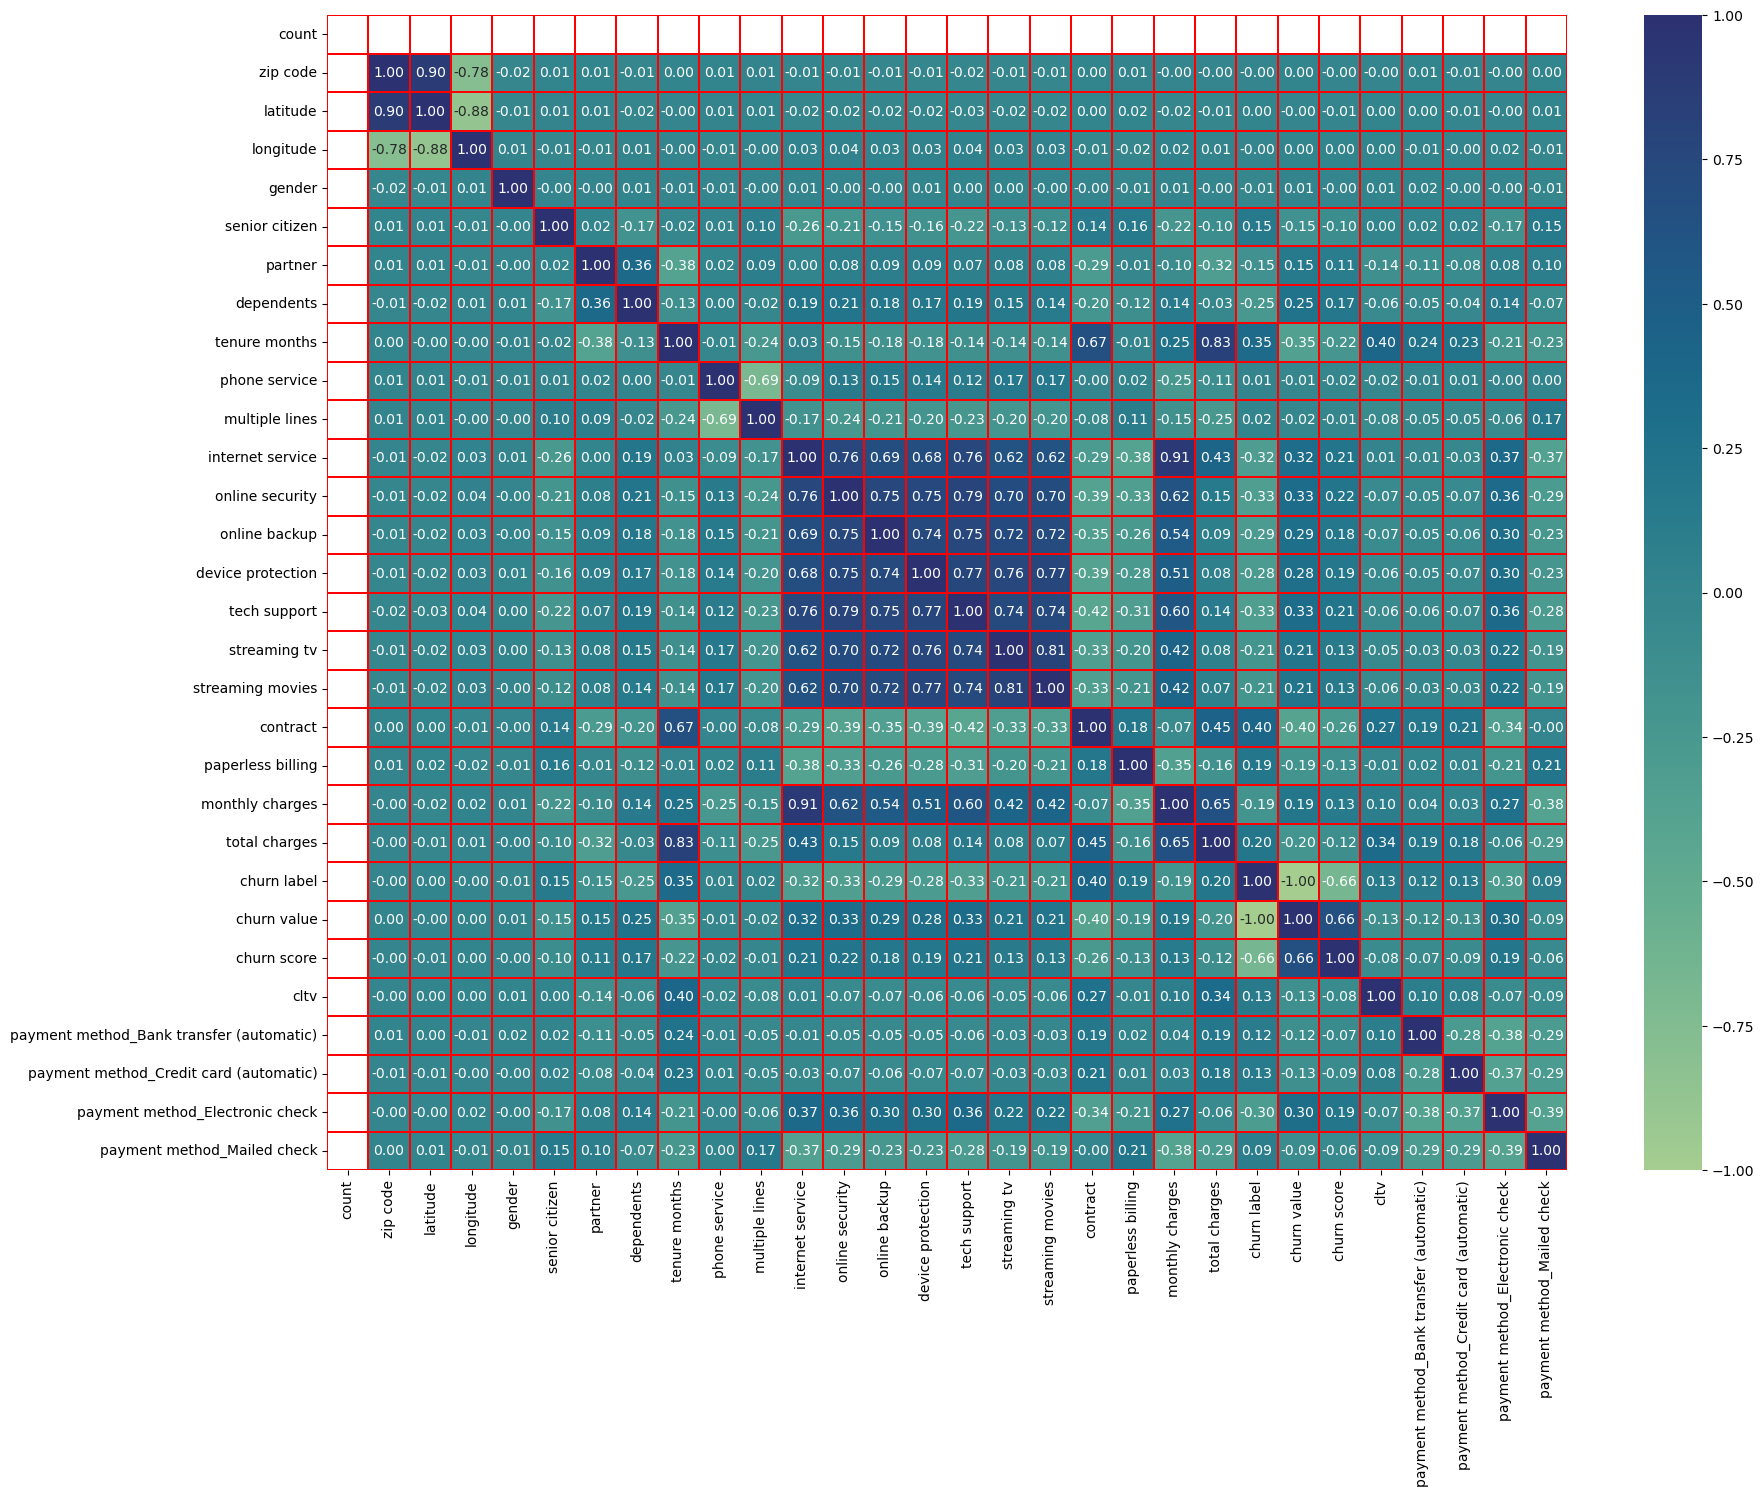

In [123]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap="crest", linewidths=0.01, linecolor='red' )

### Multicolinearity checking ---

In [124]:
def corr_chk(df, threshold):
    corr_matrix = df.corr()
    high_corr = set()
    for row in range(len(corr_matrix.columns)):
        for col in range(row):
            if abs(corr_matrix.iloc[row, col]) > threshold:
                high_corr.add(corr_matrix.columns[row])
    return high_corr

In [125]:
print(corr_chk(df, 0.8))

{'longitude', 'monthly charges', 'latitude', 'streaming movies', 'churn value', 'total charges'}


# Conclusion-

In the dataset {'longitude', 'monthly charges', 'streaming movies', 'latitude', 'churn value'} have multicolinearity. 
1. "Longitude" and "Latitude" are independent although they have higher corelation.
2. "monthly charge" are 0.91 colinear with "internet service", it have an relation.
3. "Streaming movies" are .81 colinear with "streaming tv". but both are indicating different thing.
4. "churn value" are -1 colinear with 'churn label". Both are indicate same thing, so we drop one of them.

In [126]:
df.drop(columns=['churn label', 'count'], axis=1, inplace=True)

In [130]:
df['total charges'] = df['total charges'].replace({np.nan : df['total charges'].mean()})

In [131]:
df['total charges'].isna().sum()

np.int64(0)

In [132]:
df.to_csv("Data/Cleaned-Telco-data.csv", index=False)